In [ ]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

# ── Custom Reward Wrapper ─────────────────────────────────────────────────────

class FrozenLakeCustomReward(gym.RewardWrapper):
    """
    Replaces FrozenLake's default reward (0 everywhere, 1 at goal) with:
        +100  reaching the Goal tile  (G)
        -50   falling into a Hole     (H)
        -1    every other step        (F / S) — penalises dawdling
    """

    def __init__(self, env):
        super().__init__(env)

    def reward(self, reward):
        # `reward` here is the raw value Gymnasium just returned.
        # We ignore it entirely and re-derive from the current state.
        desc = self.unwrapped.desc          # 2-D array of tile bytes, e.g. b'H', b'G', b'F', b'S'
        s    = self.unwrapped.s             # current state index (int)
        nrow = self.unwrapped.nrow
        ncol = self.unwrapped.ncol

        row, col = divmod(s, ncol)
        tile = desc[row, col].decode("utf-8")   # 'H', 'G', 'F', or 'S'

        if tile == "G":
            return 100.0
        elif tile == "H":
            return -50.0
        else:                               # 'F' or 'S'
            return -1.0


def build_env(slippery=False):
    base_env = gym.make("FrozenLake5x5-v1", is_slippery=slippery, render_mode="ansi")
    return FrozenLakeCustomReward(base_env)   # wrap it — everything else stays the same

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]

            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def policy_evaluate_graphical(env, policy, eval_episodes=100, max_steps=100):
    """
    Evaluates the performance of a policy strictly from the starting point.
    Returns average reward and average episode length.
    """
    total_rewards = []
    episode_lengths = []

    for _ in range(eval_episodes):
        state, _ = env.reset()
        episode_reward = 0
        steps = 0

        for _ in range(max_steps):
            action = policy[state]
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            episode_reward += reward
            steps += 1

            if terminated or truncated:
                break
            
            state = next_state

        total_rewards.append(episode_reward)
        episode_lengths.append(steps)

    return np.mean(total_rewards), np.mean(episode_lengths)

def plot_evaluation_metrics(avg_rewards, avg_lengths):
    """
    Plots the collected metrics from policy_iteration, updated for 
    the new reward scheme (-50 hole, 100 goal, -1 step).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Average Reward
    ax1.plot(avg_rewards, marker='o', color='forestgreen', label='Avg Reward', linewidth=2)
    ax1.axhline(y=0, color='crimson', linestyle='-', alpha=0.5, label='Zero Reward Line')
    ax1.axhline(y=100, color='gold', linestyle='--', alpha=0.8, label='Max Goal Reward (100)')
    
    # Dynamically scale the y-axis to capture negative values well, but keep top above 100
    y_min = min(-60.0, min(avg_rewards) - 10) if avg_rewards else -60.0
    ax1.set_ylim([y_min, 110.0])

    ax1.set_title("Average Reward per Iteration", fontsize=12)
    ax1.set_xlabel("Policy Iteration", fontsize=10)
    ax1.set_ylabel("Average Reward", fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # Plot Average Episode Length
    ax2.plot(avg_lengths, marker='o', color='royalblue', linewidth=2)
    ax2.set_title("Average Episode Length per Iteration", fontsize=12)
    ax2.set_xlabel("Policy Iteration", fontsize=10)
    ax2.set_ylabel("Average Steps", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    

In [74]:
import random
from tqdm import tqdm

def policy_evaluation_monte(policy, gamma, n_episodes=10000, max_steps=100, iteration_idx=1, slippery=False):
    n_states = policy.shape[0]
    env = build_env(slippery=slippery)
    
    q_sum = np.zeros((n_states, env.action_space.n))
    returns_count = np.zeros((n_states, env.action_space.n))
    
    for episode in tqdm(range(n_episodes), desc=f"Iter {iteration_idx} MC Eval", leave=False, position=1):
        env.reset()
        episode_history = []
        
        state = random.randint(0, n_states - 1) 
        env.unwrapped.s = state 
        
        action = random.randint(0, env.action_space.n - 1)
        
        #episode generation 
        for step in range(max_steps):
            next_state, reward, terminated, truncated, info = env.step(action)
            
            episode_history.append((state, action, reward))
            
            if terminated or truncated:
                break
                
            state = next_state
            action = policy[state] 

        #episode return
        G = 0
        visited_in_episode = set()
        
        for t in reversed(range(len(episode_history))):
            s_t, a_t, r_t = episode_history[t]
            
            G = r_t + gamma * G
            
            #first visit only
            if (s_t, a_t) not in visited_in_episode:
                visited_in_episode.add((s_t, a_t))
                q_sum[s_t, a_t] += G
                returns_count[s_t, a_t] += 1
            
    env.close()
    q_values_matrix = np.divide(q_sum, returns_count, out=np.zeros_like(q_sum), where=returns_count != 0)
    return q_values_matrix

In [75]:
def policy_iteration(env, gamma=0.99, max_iterations=5000, slippery=False, episodes = 1000, max_steps=100 ):
   
    n_states = env.observation_space.n
    policy = np.zeros(n_states, dtype=int)
    
    avg_rewards_history = []
    avg_lengths_history = []

    # Outer progress bar for tracking total policy iterations
    outer_pbar = tqdm(total=max_iterations, desc="Overall Policy Iterations", position=0, leave=True)

    for iteration in range(max_iterations):
        # 1. Evaluate current policy graphically and store metrics
        avg_r, avg_l = policy_evaluate_graphical(env, policy)
        avg_rewards_history.append(avg_r)
        avg_lengths_history.append(avg_l)


        q_val_matrix = policy_evaluation_monte(policy, gamma, iteration_idx=iteration + 1, slippery=slippery, n_episodes=episodes, max_steps=max_steps)
        
        new_policy = np.argmax(q_val_matrix, axis=1)
        
        
        if np.array_equal(new_policy, policy):
            outer_pbar.update(1)
            outer_pbar.close()
            print(f"\nPolicy converged after {iteration + 1} iterations!")
            return policy, avg_rewards_history, avg_lengths_history
            
        policy = new_policy
        outer_pbar.update(1)

    outer_pbar.close()
    return policy, avg_rewards_history, avg_lengths_history

Overall Policy Iterations:   7%|▋         | 7/100 [00:05<01:13,  1.27it/s]



Policy converged after 7 iterations!


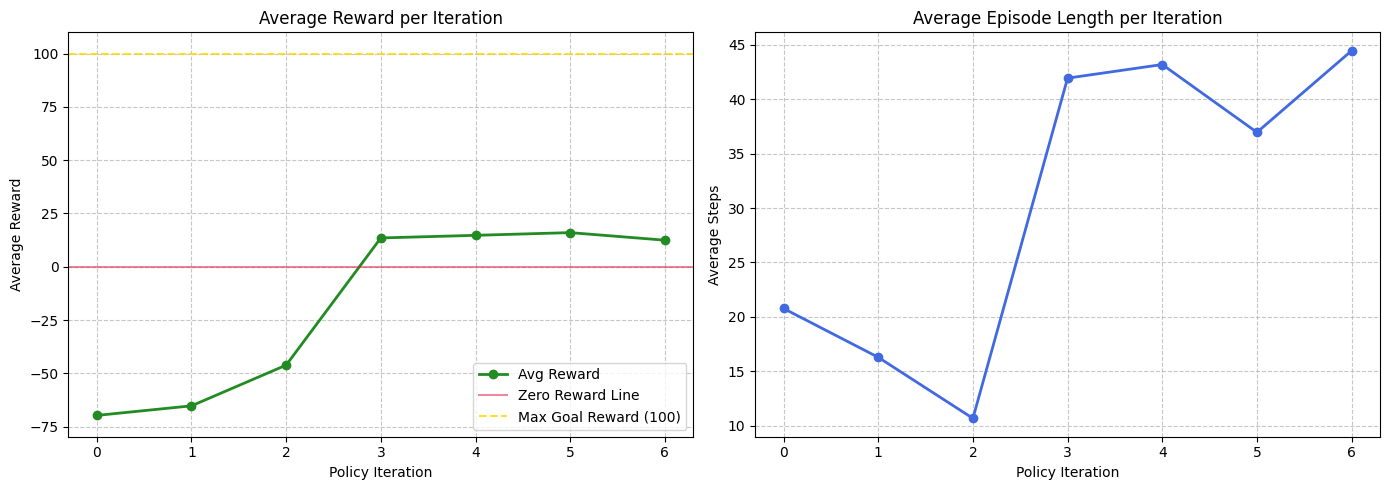

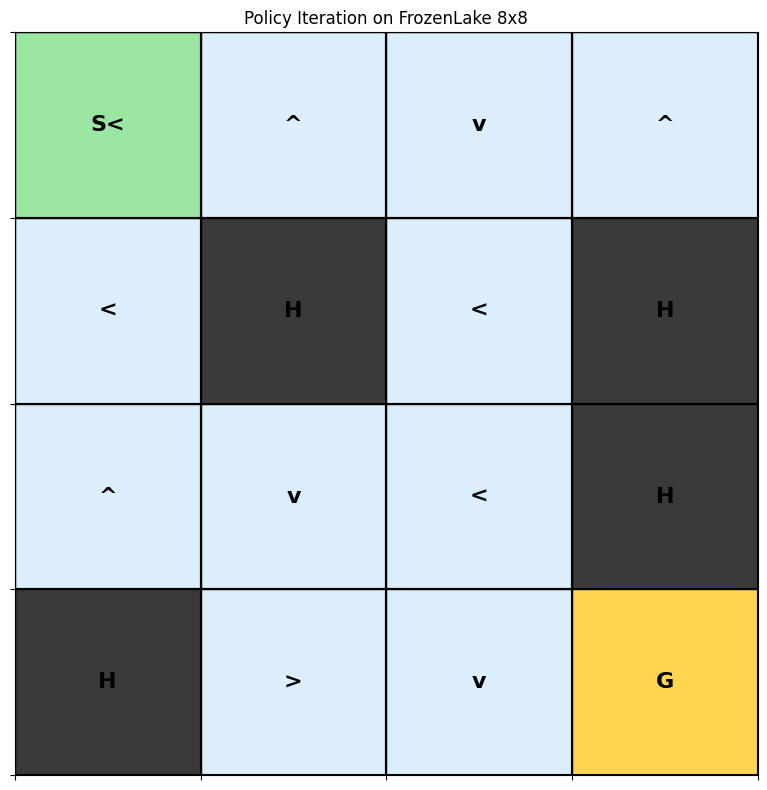

In [76]:
def run(gamma=0.99, episodes=1000, max_steps=100, max_iterations=100, slippery=False):
    
    env = build_env(slippery=slippery)
    
    pi_policy, avg_rewards, avg_lengths = policy_iteration(env,gamma=gamma, max_iterations=max_iterations, slippery=slippery, episodes=episodes, max_steps=max_steps)

    plot_evaluation_metrics(avg_rewards, avg_lengths)
    
    plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")

run(slippery=True, episodes = 10000, max_steps=100, max_iterations=100)